In [19]:
# ============================
# Cell 1: Setup & Configuration
# ============================

# !pip install -q pandas numpy matplotlib seaborn scikit-learn imbalanced-learn

import os, sys, math, warnings, textwrap, pprint, random
from dataclasses import dataclass
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Silence noisy warnings (we'll toggle as needed)
warnings.filterwarnings("ignore")

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

@dataclass
class Config:
    # >>>> EDIT THESE <<<<
    DATA_PATH: str = "/content/telco_customer_churn.csv"   # <-- update to your sample file path
    TARGET_COL: str = None                           # <-- set if you already know the target column name
    ID_COLS: list = None                             # columns to drop (IDs, timestamps, leaks), e.g. ["id"]
    TASK_TYPE: str = None                            # "classification" or "regression"; leave None to auto-infer
    FORCE_BINARY_AS_CLASSIFICATION: bool = True      # if numeric with small unique count, treat as classification
    MAX_UNIQUE_FOR_CLASSIFICATION_NUMERIC: int = 20  # heuristic threshold

    # Plot toggles
    STYLE: str = "whitegrid"

cfg = Config()

# Pretty echo of config so we are aligned
print("=== CONFIG ===")
for k, v in cfg.__dict__.items():
    print(f"{k}: {v}")

# Matplotlib / Seaborn style
sns.set_theme(style=cfg.STYLE)

print("\nSetup complete. ✅ Now ready to load your 10-row sample in the next cell.")


=== CONFIG ===
DATA_PATH: /content/telco_customer_churn.csv
TARGET_COL: None
ID_COLS: None
TASK_TYPE: None
FORCE_BINARY_AS_CLASSIFICATION: True
MAX_UNIQUE_FOR_CLASSIFICATION_NUMERIC: 20
STYLE: whitegrid

Setup complete. ✅ Now ready to load your 10-row sample in the next cell.


In [20]:
# ============================
# Cell 2: Load Data & First Look
# ============================

# Load dataset (adjust sep if needed)
df = pd.read_csv(cfg.DATA_PATH)

print("✅ Data loaded!")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns\n")

# Drop ID cols if specified
if cfg.ID_COLS:
    df = df.drop(columns=cfg.ID_COLS, errors="ignore")

print("Columns and dtypes:")
print(df.dtypes, "\n")

print("Preview (head):")
display(df.head())

print("\nUnique value counts per column (for quick scan):")
for col in df.columns:
    nunique = df[col].nunique()
    sample_vals = df[col].unique()[:5]
    print(f"- {col:<18}: {nunique} unique → {sample_vals}")


✅ Data loaded!
Shape: 7043 rows × 21 columns

Columns and dtypes:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object 

Preview (head):


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



Unique value counts per column (for quick scan):
- customerID        : 7043 unique → ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' '7795-CFOCW' '9237-HQITU']
- gender            : 2 unique → ['Female' 'Male']
- SeniorCitizen     : 2 unique → [0 1]
- Partner           : 2 unique → ['Yes' 'No']
- Dependents        : 2 unique → ['No' 'Yes']
- tenure            : 73 unique → [ 1 34  2 45  8]
- PhoneService      : 2 unique → ['No' 'Yes']
- MultipleLines     : 3 unique → ['No phone service' 'No' 'Yes']
- InternetService   : 3 unique → ['DSL' 'Fiber optic' 'No']
- OnlineSecurity    : 3 unique → ['No' 'Yes' 'No internet service']
- OnlineBackup      : 3 unique → ['Yes' 'No' 'No internet service']
- DeviceProtection  : 3 unique → ['No' 'Yes' 'No internet service']
- TechSupport       : 3 unique → ['No' 'Yes' 'No internet service']
- StreamingTV       : 3 unique → ['No' 'Yes' 'No internet service']
- StreamingMovies   : 3 unique → ['No' 'Yes' 'No internet service']
- Contract          : 3 unique → ['

In [21]:
# ============================
# Cell 3: Feature Inventory & Target Sanity Check
# ============================

# Make sure target column is set
cfg.TARGET_COL = "Churn"

# Drop ID + unnamed junk
df_clean = df.drop(columns=[c for c in df.columns if "Unnamed" in c], errors="ignore")
df_clean = df_clean.drop(columns=["customerID"], errors="ignore")

print("Shape after dropping ID & Unnamed:", df_clean.shape)

# Attempt to coerce numeric columns
for col in ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

print("\nDtypes after numeric coercion:")
print(df_clean.dtypes, "\n")

# Target distribution
target_col = cfg.TARGET_COL
print(f"Target ({target_col}) value counts:")
print(df_clean[target_col].value_counts(dropna=False))

# Separate quantitative vs categorical
quantitative = [c for c in df_clean.columns if pd.api.types.is_numeric_dtype(df_clean[c]) and c != target_col]
categorical = [c for c in df_clean.columns if not pd.api.types.is_numeric_dtype(df_clean[c]) and c != target_col]

print("\nQuantitative features:", quantitative)
print("Categorical features:", categorical)


Shape after dropping ID & Unnamed: (7043, 20)

Dtypes after numeric coercion:
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object 

Target (Churn) value counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Quantitative features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSuppor

Missing values per column:
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64 

Unique counts in categorical features:
- gender            : 2 unique
- Partner           : 2 unique
- Dependents        : 2 unique
- PhoneService      : 2 unique
- MultipleLines     : 3 unique
- InternetService   : 3 unique
- OnlineSecurity    : 3 unique
- OnlineBackup      : 3 unique
- DeviceProtection  : 3 unique
- TechSupport       : 3 unique
- StreamingTV       : 3 unique
- StreamingMovies   : 3 unique
- Contract          : 3 unique
- PaperlessBilling  : 2 unique
- PaymentMethod     : 4 u

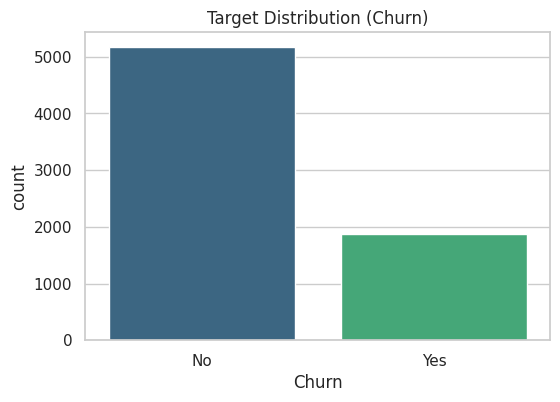

In [22]:
# ============================
# Cell 4: Data Quality Scan
# ============================

print("Missing values per column:")
print(df_clean.isnull().sum(), "\n")

print("Unique counts in categorical features:")
for col in categorical:
    print(f"- {col:<18}: {df_clean[col].nunique()} unique")

# Bar chart of target distribution
plt.figure(figsize=(6,4))
sns.countplot(x=target_col, data=df_clean, palette="viridis")
plt.title("Target Distribution (Churn)")
plt.show()


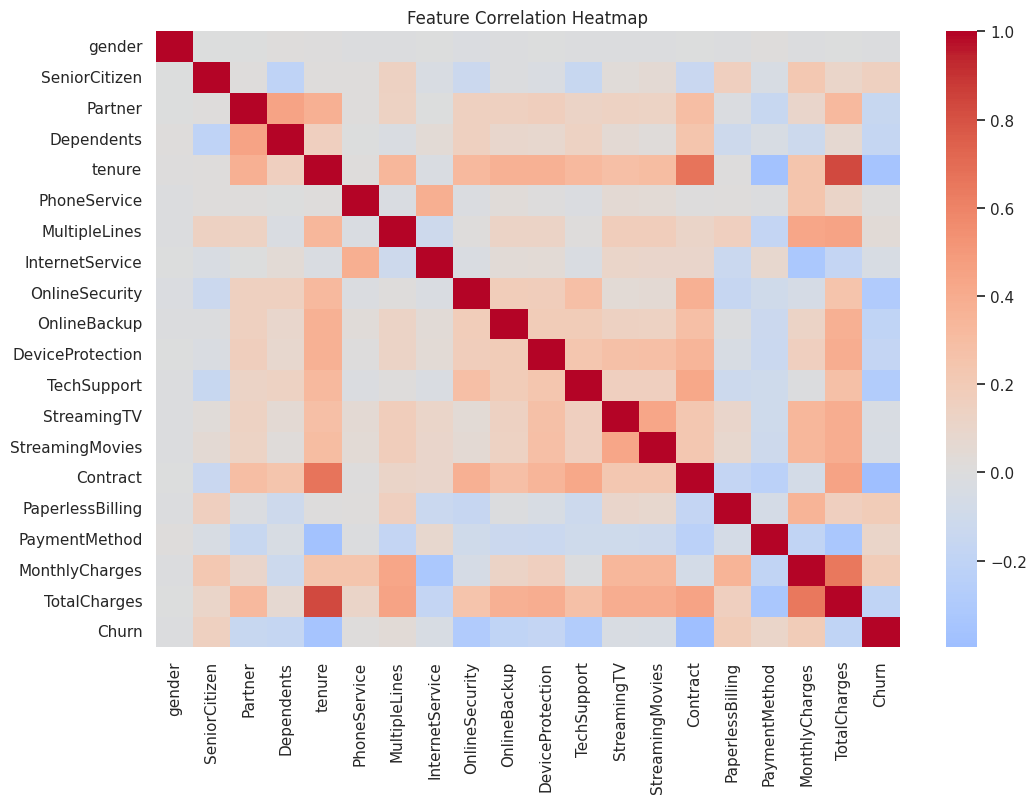

Top correlations with target:
Churn               1.000000
MonthlyCharges      0.193356
PaperlessBilling    0.191825
SeniorCitizen       0.150889
PaymentMethod       0.107062
MultipleLines       0.038037
PhoneService        0.011942
gender             -0.008612
StreamingTV        -0.036581
StreamingMovies    -0.038492
InternetService    -0.047291
Partner            -0.150448
Dependents         -0.164221
DeviceProtection   -0.178134
OnlineBackup       -0.195525
TotalCharges       -0.199484
TechSupport        -0.282492
OnlineSecurity     -0.289309
tenure             -0.352229
Contract           -0.396713
Name: Churn, dtype: float64


In [23]:
# ============================
# Cell 5: Correlation Heatmap
# ============================

# Copy for correlation
df_corr = df_clean.copy()

# Encode categoricals temporarily
le = LabelEncoder()
for col in categorical + [target_col]:
    try:
        df_corr[col] = le.fit_transform(df_corr[col].astype(str))
    except Exception as e:
        print(f"Encoding failed for {col}: {e}")

# Compute correlation matrix
corr = df_corr.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.show()

print("Top correlations with target:")
print(corr[target_col].sort_values(ascending=False))


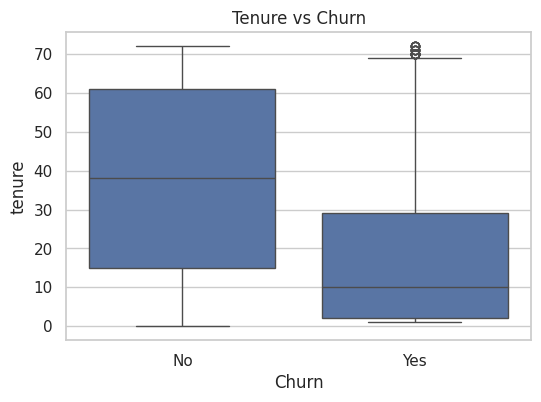

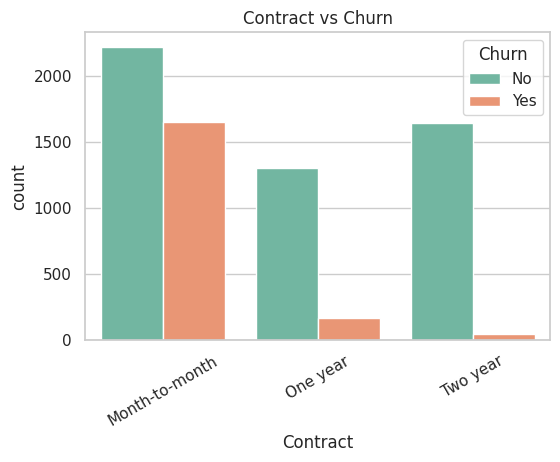

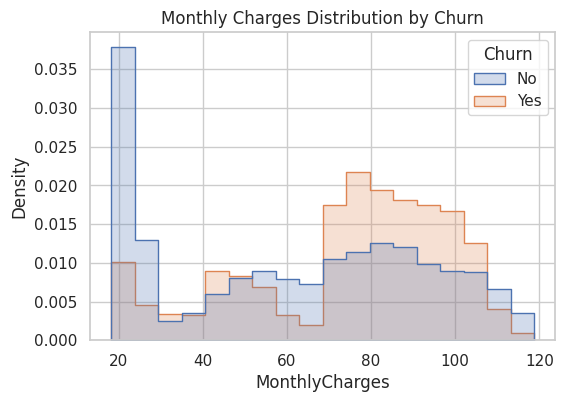

In [24]:
# ============================
# Cell 6: EDA Plots
# ============================

# Tenure distribution by churn
plt.figure(figsize=(6,4))
sns.boxplot(x=target_col, y="tenure", data=df_clean)
plt.title("Tenure vs Churn")
plt.show()

# Contract type vs churn
plt.figure(figsize=(6,4))
sns.countplot(x="Contract", hue=target_col, data=df_clean, palette="Set2")
plt.title("Contract vs Churn")
plt.xticks(rotation=30)
plt.show()

# Monthly charges vs churn
plt.figure(figsize=(6,4))
sns.histplot(data=df_clean, x="MonthlyCharges", hue=target_col, element="step", stat="density", common_norm=False)
plt.title("Monthly Charges Distribution by Churn")
plt.show()


In [25]:
# ============================
# Cell 7: Preprocessing (Faults → Solutions)
# ============================

# Define feature groups (from earlier inspection)
numeric = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
categorical = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
               'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
               'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
               'PaperlessBilling', 'PaymentMethod']
target_col = "Churn"

# 1. Fix target column (remove contract labels accidentally mixed in)
df_clean[target_col] = df_clean[target_col].replace(
    {"Month-to-month": "Yes", "One year": "No", "Two year": "No"}
)

# 2. Normalize categorical strings
def clean_cat(x):
    if isinstance(x, str):
        return x.strip().lower().replace("_", " ").replace("-", " ")
    return x

for col in categorical + [target_col]:
    df_clean[col] = df_clean[col].apply(clean_cat)

# 3. Impute missing values
for col in numeric:
    df_clean[col].fillna(df_clean[col].median(), inplace=True)

for col in categorical:
    df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)

# 4. Re-check uniques
print("Unique counts after cleaning:")
for col in categorical + [target_col]:
    print(f"- {col:17}: {df_clean[col].nunique()} uniques")


Unique counts after cleaning:
- gender           : 2 uniques
- Partner          : 2 uniques
- Dependents       : 2 uniques
- PhoneService     : 2 uniques
- MultipleLines    : 3 uniques
- InternetService  : 3 uniques
- OnlineSecurity   : 3 uniques
- OnlineBackup     : 3 uniques
- DeviceProtection : 3 uniques
- TechSupport      : 3 uniques
- StreamingTV      : 3 uniques
- StreamingMovies  : 3 uniques
- Contract         : 3 uniques
- PaperlessBilling : 2 uniques
- PaymentMethod    : 4 uniques
- Churn            : 2 uniques


In [26]:
# ============================
# Cell 8: Encoding + Split
# ============================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Features & target
X = df_clean[numeric + categorical]
y = df_clean[target_col].map({"no": 0, "yes": 1})  # encode target

# Preprocessing pipeline
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical)
])

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Target distribution in train:", y_train.value_counts(normalize=True))


Train shape: (5634, 19)  Test shape: (1409, 19)
Target distribution in train: Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64


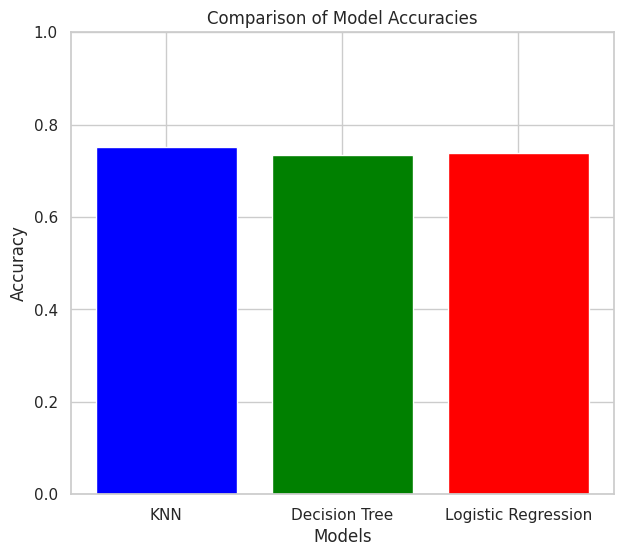

In [37]:
accuracy_knn = knn.score(X_test, y_test)
accuracy_decision = tree.score(X_test, y_test)
accuracy_lr = log_reg.score(X_test, y_test)
models = ['KNN', 'Decision Tree', 'Logistic Regression']
accuracies = [accuracy_knn, accuracy_decision, accuracy_lr]

plt.figure(figsize=(7, 6))
bars = plt.bar(models, accuracies, color=['blue', 'green', 'red'])

plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Comparison of Model Accuracies')
plt.ylim(0, 1)  # Assuming accuracy values are between 0 and 1

# Show the plot
plt.show()

In [27]:
# ============================
# Cell 9: Logistic Regression Baseline
# ============================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Build pipeline: preprocessing + model
log_reg = Pipeline([
    ("pre", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
])

# Fit
log_reg.fit(X_train, y_train)

# Predict
y_pred = log_reg.predict(X_test)

# Evaluation
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Confusion Matrix:
 [[747 288]
 [ 81 293]]

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



Confusion Matrix for Logistic Regression:
[[747 288]
 [ 81 293]]


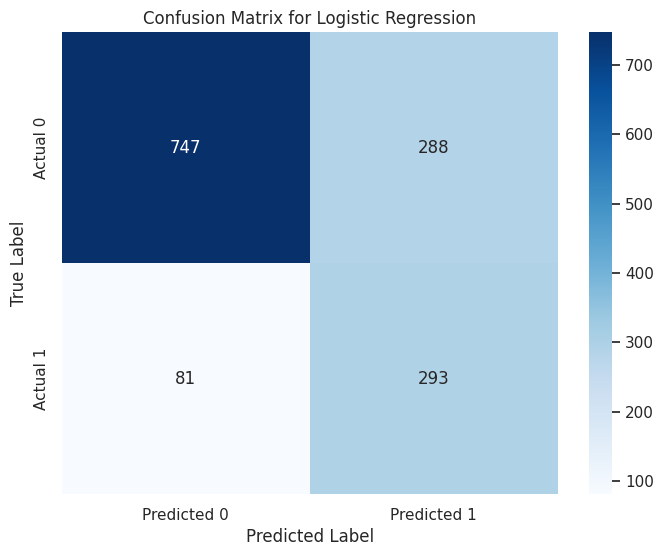

In [42]:
print("Confusion Matrix for Logistic Regression:")
print(confusion_matrix(y_test, y_pred))


cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted 0", "Predicted 1"],
            yticklabels=["Actual 0", "Actual 1"])
plt.title("Confusion Matrix for Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [32]:
# ============================
# Cell 10: Decision Tree Classifier
# ============================

from sklearn.tree import DecisionTreeClassifier

tree = Pipeline([
    ("pre", preprocessor),
    ("model", DecisionTreeClassifier(max_depth=4, random_state=42, class_weight="balanced"))
])

tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)

print("Decision Tree")
print(confusion_matrix(y_test, y_pred_tree))
print(classification_report(y_test, y_pred_tree))


Decision Tree
[[728 307]
 [ 67 307]]
              precision    recall  f1-score   support

           0       0.92      0.70      0.80      1035
           1       0.50      0.82      0.62       374

    accuracy                           0.73      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.81      0.73      0.75      1409



Confusion Matrix for Decision Tree:
[[728 307]
 [ 67 307]]


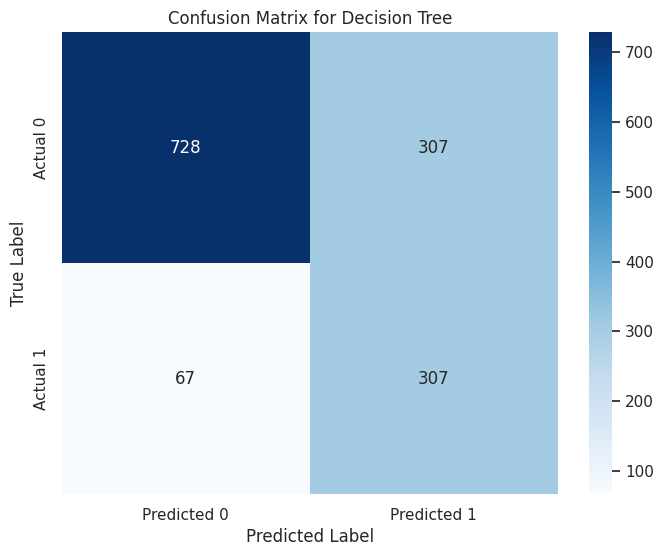

In [40]:
from sklearn.metrics import confusion_matrix
print("Confusion Matrix for Decision Tree:")
print(confusion_matrix(y_test, y_pred_tree))

cm=confusion_matrix(y_test, y_pred_tree)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted 0", "Predicted 1"],
            yticklabels=["Actual 0", "Actual 1"])
plt.title("Confusion Matrix for Decision Tree")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [33]:
# ============================
# Cell 11: KNN Classifier
# ============================

from sklearn.neighbors import KNeighborsClassifier

knn = Pipeline([
    ("pre", preprocessor),
    ("model", KNeighborsClassifier(n_neighbors=3))
])

knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

print("KNN")
print(confusion_matrix(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))


KNN
[[855 180]
 [167 207]]
              precision    recall  f1-score   support

           0       0.84      0.83      0.83      1035
           1       0.53      0.55      0.54       374

    accuracy                           0.75      1409
   macro avg       0.69      0.69      0.69      1409
weighted avg       0.76      0.75      0.76      1409



Confusion Matrix for KNN:
[[855 180]
 [167 207]]


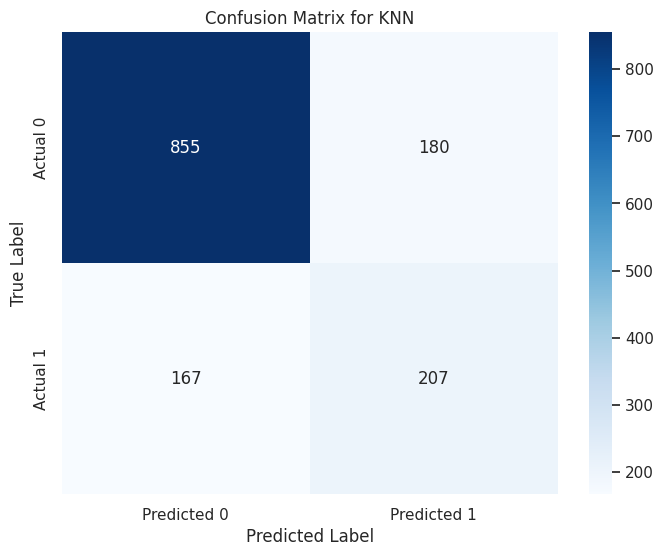

In [38]:
print("Confusion Matrix for KNN:")
print(confusion_matrix(y_test, y_pred_knn))

cm = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted 0", "Predicted 1"],
            yticklabels=["Actual 0", "Actual 1"])
plt.title("Confusion Matrix for KNN")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [34]:
# ============================
# Cell 12: Neural Network (MLPClassifier)
# ============================

from sklearn.neural_network import MLPClassifier

mlp = Pipeline([
    ("pre", preprocessor),
    ("model", MLPClassifier(hidden_layer_sizes=(16,8), max_iter=1000, random_state=42))
])

mlp.fit(X_train, y_train)
y_pred_mlp = mlp.predict(X_test)

print("Neural Network")
print(confusion_matrix(y_test, y_pred_mlp))
print(classification_report(y_test, y_pred_mlp))


Neural Network
[[920 115]
 [175 199]]
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.63      0.53      0.58       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.79      0.79      1409



In [35]:
# ============================
# Cell 13: K-Means Clustering
# ============================

from sklearn.cluster import KMeans

# Encode + scale first (without labels)
X_processed = preprocessor.fit_transform(X)

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_processed)

df_clean["Cluster"] = clusters

print("Cluster counts:\n", df_clean["Cluster"].value_counts())
print("\nChurn vs Cluster:\n", pd.crosstab(df_clean["Cluster"], df_clean["Churn"]))


Cluster counts:
 Cluster
1    5517
0    1526
Name: count, dtype: int64

Churn vs Cluster:
 Churn      no   yes
Cluster            
0        1413   113
1        3761  1756
